In [2]:
cd("/home/ritaferi/Phd/SSDdev/")
using Pkg
Pkg.activate(".")
Pkg.instantiate()

using SolidStateDetectors
using Unitful
ENV["GKSwstype"] = "png"

using Plots
gr()
using LegendHDF5IO
using HDF5



  Activating project at `~/Phd/SSDdev`


In [3]:
using Random
using SpecialFunctions
using Distributions

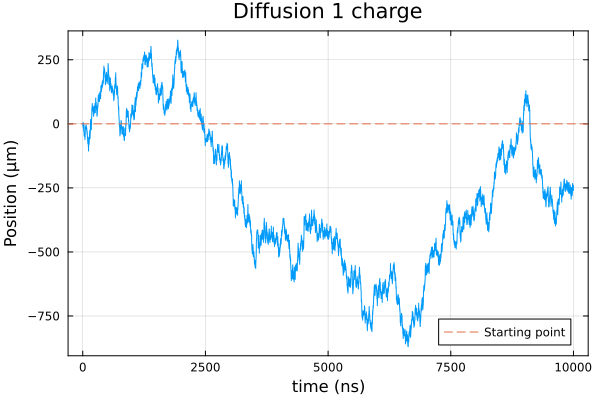

In [4]:


function single_charge_random_walk()

    # parametri fisici
    D = 28.9          # micron^2/ns
    Δt = 1.0          # ns
    t_max = 10000

    Nt = Int(t_max/Δt)

    # posizione iniziale
    x = zeros(Nt)
    x[1] = 0

    σ = sqrt(2*D*Δt)

    for i in 2:Nt
        step = σ * randn()
        x[i] = x[i-1] + step
    end

    t = (1:Nt) .* Δt

    plot( t, x, 
        ylabel="Position (µm)",
        xlabel="time (ns)",
        title="Diffusion 1 charge", label = "")
    hline!([x[1]], ls = :dash, frame = :box , label = "Starting point" )
    #hline!([1100], ls = :dash, frame = :box, label = "FCCD")

end

single_charge_random_walk()

## 3D linear

In [5]:
0.005/(Nd(0))

UndefVarError: UndefVarError: `Nd` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Numero precipitati Li: 1200
Carica trapped step 427


┌ Info: Saved animation to /home/ritaferi/Phd/ChargeTrappingModel_dev/gif/single_charge_trapping_collected.gif
└ @ Plots /home/ritaferi/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/home/ritaferi/Phd/ChargeTrappingModel_dev/gif/single_charge_trapping_collected.gif")
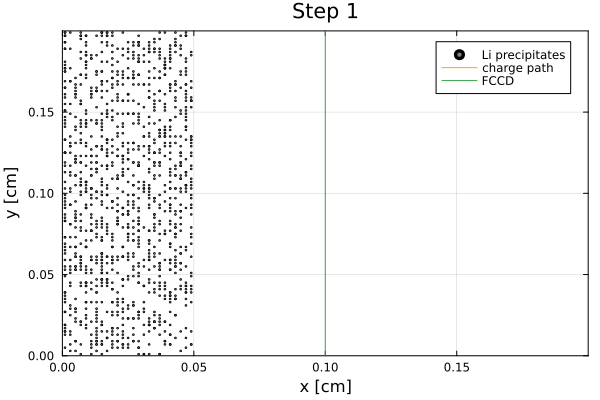

In [6]:

function single_charge_2D_trapping_gif()

    # --------------------------
    # Geometria
    # --------------------------
    Lx = 0.2
    Ly = 0.2
    Lz = 0.2

    r_Li = 0.002      # cm (20 µm voxel)
    FCCD_cm = 0.1
    PN_cm = 0.11

    # --------------------------
    # Parametri diffusione carica
    # --------------------------
    D = 28.9
    Δt = 1.0
    t_max = 10000
    Nt = Int(t_max/Δt)

    σ = sqrt(2*D*Δt)*1e-4  # µm → cm

    # --------------------------
    # Generazione griglia Li
    # --------------------------
    function generate_Li_grid(Lx, Ly, Lz, voxel)

        nx = Int(Lx / voxel)
        ny = Int(Ly / voxel)
        nz = Int(Lz / voxel)

        Li_grid = falses(nx,ny,nz)

        li_depth = 0.05   # 500 µm = 0.05 cm
        conc = 0.005

        for ix in 1:nx
            depth = (ix-1)*voxel

            prob = depth < li_depth ? conc : 0.0

            for iy in 1:ny, iz in 1:nz
                if rand() < prob
                    Li_grid[ix,iy,iz] = true
                end
            end
        end

        return Li_grid, nx, ny, nz
    end

    Li_grid, nx, ny, nz = generate_Li_grid(Lx,Ly,Lz,r_Li)

    # --------------------------
    # Estrazione posizioni Li (per plotting 2D)
    # --------------------------
    x_positions = Float64[]
    y_positions = Float64[]

    for ix in 1:nx, iy in 1:ny, iz in 1:nz
        if Li_grid[ix,iy,iz]
            x = (ix-0.5)*r_Li
            y = (iy-0.5)*r_Li
            push!(x_positions,x)
            push!(y_positions,y)
        end
    end

    println("Numero precipitati Li: ", length(x_positions))

    # --------------------------
    # Posizione iniziale carica
    # --------------------------
    x_charge = 0.045
    y_charge = 0.1
    z_charge = 0.1

    xs = [x_charge]
    ys = [y_charge]

    trapped = false

    # --------------------------
    # Animazione
    # --------------------------
    anim = @animate for i in 1:Nt

    # moto browniano
    x_charge += σ*randn()
    y_charge += σ*randn()
    z_charge += σ*randn()

    x_charge = clamp(x_charge,0,Lx)
    y_charge = clamp(y_charge,0,Ly)
    z_charge = clamp(z_charge,0,Lz)

    ix = clamp(Int(floor(x_charge/r_Li))+1,1,nx)
    iy = clamp(Int(floor(y_charge/r_Li))+1,1,ny)
    iz = clamp(Int(floor(z_charge/r_Li))+1,1,nz)

    push!(xs,x_charge)
    push!(ys,y_charge)

    scatter(x_positions,y_positions,
        ms=1,
        color=:grey,
        label="Li precipitates", frame = :box)

    plot!(xs,ys,  
        color=:orange,
        label="charge path")

    vline!([FCCD_cm],label="FCCD")

    xlims!(0,Lx)
    ylims!(0,Ly)

    xlabel!("x [cm]")
    ylabel!("y [cm]")

    title!("Step $i")

    # DOPO il plot controlli le condizioni
    if Li_grid[ix,iy,iz]
        println("Carica trapped step $i")
        break
    end

    if x_charge >= FCCD_cm
        println("Carica raccolta step $i")
        break
    end

end

    gif(anim,"/home/ritaferi/Phd/ChargeTrappingModel_dev/gif/single_charge_trapping_collected.gif",fps=20)

end

single_charge_2D_trapping_gif()

# 3D impurity profile

In [7]:
t_ann = 18 * 60       # 18 min in sec
T_ann = 623

#diffusione
R = 1.98
H = 11800
D0 = 2.5e-3
Ns = 10^(21.27 - 2610 / T_ann)
D_Li = D0 * exp(-H / (R * T_ann))

1.7518396803995296e-7

In [11]:
0.005/(Ns*(r_Li*r_Li*r_Li))

5.191419413759565e-12

In [19]:
5*1e6/Ns

4.153135531007652e-11

In [8]:
D = 28.9           # diffusione [µm^2/ns]
Δt = 1.0           # ns
t_max = 10000      # ns
Nt = Int(t_max / Δt)
σ = sqrt(2 * D * Δt) * 1e-4  # µm -> cm

# Raggio per cattura Li (ora corrisponde a un voxel)
r_Li = 0.002  # cm (20 µm)

0.002

## CCE

----

In [ ]:

function single_charge_3D_trapping_gif_LITIUM()

    Lx = 0.2
    Ly = 0.2
    Lz = 0.2

    r_Li = 0.002      # cm (20 µm voxel)
    FCCD_cm = 0.1
    PN_cm = 0.11
    t_ann = 18 * 60       # 18 min in sec
    T_ann = 623

    #diffusione
    R = 1.98
    H = 11800
    D0 = 2.5e-3
    Ns = 10^(21.27 - 2610 / T_ann)
    D_Li = D0 * exp(-H / (R * T_ann))
    # --------------------------
    # Parametri diffusione carica
    # --------------------------
    D = 28.9
    Δt = 1.0
    t_max = 10000
    Nt = Int(t_max/Δt)

    σ = sqrt(2*D*Δt)*1e-4  # µm → cm


    # --------------------------
    # Generazione griglia Li
    # --------------------------
    function generate_Li_grid(Lx, Ly, Lz, voxel)

        nx = Int(Lx / voxel)
        ny = Int(Ly / voxel)
        nz = Int(Lz / voxel)

        Li_grid = falses(nx,ny,nz)

        li_depth = 0.01   # 500 µm = 0.05 cm
        conc = 0.005

        for ix in 1:nx, iy in 1:ny, iz in 1:nz
            depth = (ix-1)*voxel
            p_max = 0.01    # densità massima realistica
            p_voxel =  conc * erfc(depth / (2*sqrt(D_Li*t_ann)))
            prob = depth < FCCD_cm ? p_voxel : 0.0
            if rand() < prob
                Li_grid[ix, iy, iz] = true
            end
        end

        return Li_grid, nx, ny, nz
    end

    Li_grid, nx, ny, nz = generate_Li_grid(Lx,Ly,Lz,r_Li)

    # --------------------------
    # Estrazione posizioni Li (per plotting 2D)
    # --------------------------
    x_positions = Float64[]
    y_positions = Float64[]
    z_positions = Float64[]

    for ix in 1:nx, iy in 1:ny, iz in 1:nz
        if Li_grid[ix,iy,iz]
            x = (ix-0.5)*r_Li
            y = (iy-0.5)*r_Li
            z = (iz-0.5)*r_Li
            push!(x_positions,x)
            push!(y_positions,y)
            push!(z_positions,z)
        end
    end

    println("Numero precipitati Li: ", length(x_positions))

    # --------------------------
    # Posizione iniziale carica
    # --------------------------
    x_charge = 0.005
    y_charge = 0.1
    z_charge = 0.1

    xs = [x_charge]
    ys = [y_charge]
    zs = [z_charge]

    trapped = false

    # --------------------------
    # Animazione
    # --------------------------
    anim = @animate for i in 1:Nt

    # moto browniano
    x_charge += σ*randn()
    y_charge += σ*randn()
    z_charge += σ*randn()

    x_charge = clamp(x_charge,0,Lx)
    y_charge = clamp(y_charge,0,Ly)
    z_charge = clamp(z_charge,0,Lz)

    ix = clamp(Int(floor(x_charge/r_Li))+1,1,nx)
    iy = clamp(Int(floor(y_charge/r_Li))+1,1,ny)
    iz = clamp(Int(floor(z_charge/r_Li))+1,1,nz)

    push!(xs,x_charge)
    push!(ys,y_charge)
    push!(zs,z_charge)

    scatter3d(x_positions,y_positions,z_positions,
        ms=1,
        color=:grey,
        label="Li precipitates", frame = :box, size = (800,600))

    plot!(xs,ys, zs,
    
        color=:orange,
        label="charge path")

    xlims!(0,Lx)
    ylims!(0,Ly)
    zlims!(0,Lz)

    xlabel!("x [cm]")
    ylabel!("y [cm]")
    zlabel!("z [cm]")

    title!("Step $i")

    # DOPO il plot controlli le condizioni
    if Li_grid[ix,iy,iz]
        println("Carica trapped step $i")
        break
    end

    if x_charge >= FCCD_cm
        println("Carica raccolta step $i")
        break
    end

end
    mkpath("/home/ritaferi/Phd/ChargeTrappingModel_dev/gif")
    gif(anim,"/home/ritaferi/Phd/ChargeTrappingModel_dev/gif/Litium_profile.mp4",fps=50)

end

single_charge_3D_trapping_gif_LITIUM()

## My model


----------

In [88]:
using Random, Distributions

function simulate_multiple_charges( x_charge, N::Int=100)
    # --------------------------
    # Parametri Li layer
    # --------------------------
    Lx = 0.12      # profondità in cm
    Ly = 0.2       # estensione y in cm
    dx = 0.001     # passo per generare slice
    α = 1e-9      # thinning factor
    t_ann = 18*60  # annealing time [s]
    T_ann = 623

    # Parametri diffusione Li
    H = 11800
    D0 = 2.5e-3
    R = 1.98
    Ns = 10^(21.27 - 2610/T_ann)
    D_Li = D0*exp(-H/(R*T_ann))
    Nd(x) = Ns .* erfc.(x ./ (2*sqrt(D_Li*t_ann)))

    FCCD_cm = 0.11  # profondità FCCD

    # Generazione punti Li (thinning Poisson)
    x_slices = 0:dx:Lx
    x_positions = Float64[]
    y_positions = Float64[]
    for xi in x_slices
        Nd_val = Nd(xi)
        dA = dx * Ly
        λ = α * Nd_val * dA
        N_i = rand(Poisson(λ))
        for _ in 1:N_i
            push!(x_positions, xi + rand()*dx)
            push!(y_positions, rand()*Ly)
        end
    end

    println("Generati $(length(x_positions)) punti Li")

    # --------------------------
    # Parametri diffusione singola carica
    # --------------------------
    D = 28.9           # diffusione [µm^2/ns]
    Δt = 1.0           # passo temporale [ns]
    t_max = 500        # ns
    Nt = Int(t_max/Δt)
    σ = sqrt(2*D*Δt)/100  # µm -> cm

    # --------------------------
    # Simulazione N cariche
    # --------------------------
    collected = 0
    for n in 1:N
        # posizione iniziale casuale
        
        y_charge = rand()*Ly
        trapped = false

        for i in 1:Nt
            # moto browniano
            x_charge += σ*randn()
            y_charge += σ*randn()

            # condizioni al contorno
            x_charge = clamp(x_charge, 0, Lx)
            y_charge = clamp(y_charge, 0, Ly)

            # trapping Li
            for (xi, yi) in zip(x_positions, y_positions)
                if abs(x_charge - xi) < 1e-4 && abs(y_charge - yi) < 1e-4
                    trapped = true
                    println("trapped")
                    break
                end
            end

            # raccolta FCCD
            if x_charge >= FCCD_cm
                collected += 1
                break
            end

            if trapped
                break
            end
        end
    end

    println("Cariche totali: $N")
    println("Cariche raccolte alla FCCD: $collected")
    return collected
end



simulate_multiple_charges (generic function with 5 methods)

In [99]:
# Esempio con 100 cariche
N_01 = simulate_multiple_charges(0.15, 100)

Generati 385567 punti Li
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
trapped
Cariche totali: 100
Cariche raccolte alla FCCD: 67


67

In [86]:
N_001 = simulate_multiple_charges(0.0001, 100)

Generati 3986 punti Li
Cariche totali: 100
Cariche raccolte alla FCCD: 98


98